In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
import random
from collections import Counter

In [2]:
folder_path = "/anvil/projects/x-cis220051/corporate/aerospace-rf/fiot_highway2-main"

Found 16480 .npy files in '/anvil/projects/x-cis220051/corporate/aerospace-rf/fiot_highway2-main/data'

Preview of train.txt (first 10 lines):
data/003719.npy	1
data/015802.npy	2
data/015920.npy	2
data/000663.npy	0
data/001894.npy	2
data/001373.npy	2
data/012706.npy	2
data/015671.npy	2
data/006593.npy	1
data/014051.npy	0

Selected 10 files for visualization (sampled):
   013838.npy
   013641.npy
   003701.npy
   007543.npy
   012501.npy
   000706.npy
   013540.npy
   006909.npy
   009779.npy
   005277.npy

Loaded 10 arrays successfully.
  013838.npy: shape=(512, 243), dtype=float64
  013641.npy: shape=(512, 243), dtype=float64
  003701.npy: shape=(512, 243), dtype=float64
  007543.npy: shape=(512, 243), dtype=float64
  012501.npy: shape=(512, 243), dtype=float64
  000706.npy: shape=(512, 243), dtype=float64
  013540.npy: shape=(512, 243), dtype=float64
  006909.npy: shape=(512, 243), dtype=float64
  009779.npy: shape=(512, 243), dtype=float64
  005277.npy: shape=(512, 243), dtype=float

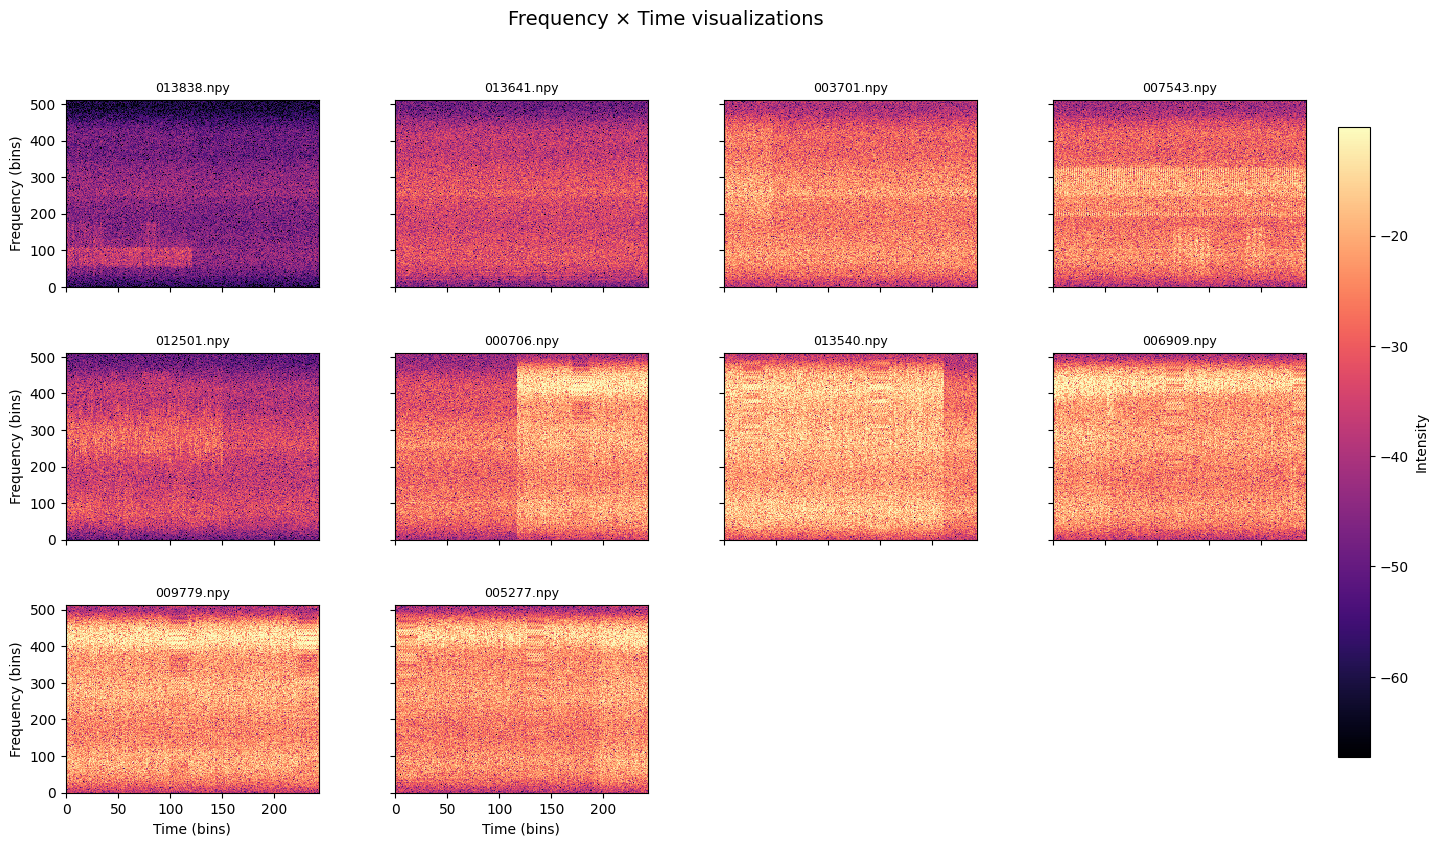

In [3]:
data_folder = os.path.join(folder_path, "data")

# visualization options
SHARED_NORMALIZATION = True
PERCENTILE_MIN = 2
PERCENTILE_MAX = 98
CMAP = "magma"
SAVE_FIG = True
OUTFILE = "freq_time_grid.png"
FIG_DPI = 200

# ====== BASIC CHECKS ======
if not os.path.exists(folder_path):
    raise FileNotFoundError(f"Dataset folder not found: {folder_path}")
if not os.path.exists(data_folder):
    raise FileNotFoundError(f"Data subfolder not found: {data_folder}")

# List .npy files
npy_files = sorted([f for f in os.listdir(data_folder) if f.endswith(".npy")])
print(f"Found {len(npy_files)} .npy files in '{data_folder}'")

if len(npy_files) == 0:
    raise SystemExit("No .npy files found — check the data folder.")

# Preview train.txt
train_file = os.path.join(folder_path, "train.txt")
if os.path.exists(train_file):
    print("\nPreview of train.txt (first 10 lines):")
    with open(train_file, "r") as fh:
        for i, line in enumerate(fh):
            print(line.strip())
            if i >= 9:
                break
else:
    print("\nWarning: train.txt not found at", train_file)

# ====== PICKING FILES TO VISUALIZE ======
n_to_sample = 10
npy_count = len(npy_files)
if npy_count <= n_to_sample:
    files = list(npy_files)  # use all if less than requested
else:
    files = random.sample(npy_files, n_to_sample)

print(f"\nSelected {len(files)} files for visualization (sampled):")
for f in files:
    print("  ", f)

# ====== HELPER to load safely ======
def safe_load(path):
    try:
        return np.load(path)
    except Exception as e:
        print(f"Failed to load {path}: {e}")
        return None

# Build full paths using data_folder (not folder_path)
paths = [os.path.join(data_folder, f) for f in files]

loaded = []
for p in paths:
    arr = safe_load(p)
    if arr is None:
        continue
    if arr.ndim != 2:
        arr = np.atleast_2d(arr)
    loaded.append((os.path.basename(p), arr))

print(f"\nLoaded {len(loaded)} arrays successfully.")
for name, arr in loaded:
    print(f"  {name}: shape={arr.shape}, dtype={arr.dtype}")

if len(loaded) == 0:
    raise SystemExit("No arrays loaded. Nothing to plot.")

if os.path.exists(train_file):
    labels = []
    with open(train_file, "r") as fh:
        for line in fh:
            parts = line.strip().split()
            if len(parts) >= 2:
                _, label = parts[:2]
                try:
                    labels.append(int(label))
                except Exception:
                    pass
    counts = Counter(labels)
    print("\nLabel counts in train split:")
    for label, cnt in sorted(counts.items()):
        print(f"  Label {label}: {cnt}")

# ====== normalization ======
if SHARED_NORMALIZATION:
    all_values = np.concatenate([np.percentile(arr, [PERCENTILE_MIN, PERCENTILE_MAX]) for _, arr in loaded])
    global_vmin = float(np.min(all_values[0::2]))
    global_vmax = float(np.max(all_values[1::2]))
    print(f"\nGlobal vmin/vmax (p{PERCENTILE_MIN},p{PERCENTILE_MAX}): {global_vmin:.4g}, {global_vmax:.4g}")
else:
    global_vmin = global_vmax = None

# ====== layout & plotting ======
n = len(loaded)
cols = min(4, n)
rows = (n + cols - 1) // cols

fig = plt.figure(figsize=(4*cols, 3*rows))
gs = GridSpec(rows, cols, figure=fig, wspace=0.3, hspace=0.35)

ims = []
for idx, (name, arr) in enumerate(loaded):
    r = idx // cols
    c = idx % cols
    ax = fig.add_subplot(gs[r, c])
    if global_vmin is None:
        vmin, vmax = np.percentile(arr, PERCENTILE_MIN), np.percentile(arr, PERCENTILE_MAX)
    else:
        vmin, vmax = global_vmin, global_vmax

    im = ax.imshow(
        arr,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax,
        cmap=CMAP
    )
    ax.set_title(name, fontsize=9)
    if r == rows - 1:
        ax.set_xlabel("Time (bins)")
    else:
        ax.set_xticklabels([])
    if c == 0:
        ax.set_ylabel("Frequency (bins)")
    else:
        ax.set_yticklabels([])
    ims.append(im)

# shared colorbar
if SHARED_NORMALIZATION:
    cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(ims[0], cax=cax, label="Intensity")
else:
    for im in ims:
        plt.colorbar(im, ax=im.axes, fraction=0.046, pad=0.04)

fig.suptitle("Frequency × Time visualizations", fontsize=14)
if SAVE_FIG:
    fig.savefig(OUTFILE, dpi=FIG_DPI, bbox_inches="tight")
    print(f"\nSaved figure to {OUTFILE}")

plt.show()